# Vitara Sleep Scoring


## Background

Data log tidur pengguna sering kali berasal dari berbagai sumber dengan struktur, skala, dan format yang tidak seragam. Agar dapat digunakan dalam sistem health scoring, data ini perlu dibersihkan, diseragamkan, dan diperkaya dengan fitur temporal agar data log tidur menjadi lebih terstruktur dan representatif.

## Problem Statement

Bagaimana cara mengintegrasikan, membersihkan, dan merekayasa fitur dari berbagai sumber dataset sleep logs yang memiliki struktur berbeda, serta mengatasi ketidakseimbangan distribusi target agar menghasilkan dataset kualitas tidur (sleep quality score) yang konsisten dan siap pakai untuk kebutuhan modeling tim AI.

## Objective

Mengembangkan end-to-end data preprocessing pipeline yang mencakup standardisasi struktur multi-sumber, pembersihan data dari duplikasi/informasi kosong, rekayasa fitur temporal (waktu tidur dan bangun) serta fitur klinis (sleep debt), hingga penerapan teknik undersampling untuk membentuk distribusi skor kualitas tidur yang seimbang.

## Business Questions

1. Bagaimana cara menyatukan struktur data log tidur yang berasal dari sumber berbeda (sleep_stress_dataset dan sleep_health_dataset) ke dalam satu skema yang seragam?  

2. Bagaimana cara melakukan normalisasi dan standardisasi skala skor kualitas tidur (quality score) agar memiliki rentang yang konsisten dan mudah diinterpretasikan oleh sistem AI?  

3. Fitur-fitur temporal dan indikator tambahan apa saja (seperti bedtime, wake time, dan sleep debt hours) yang dapat direkayasa untuk memperkaya informasi pola tidur pengguna?  

4. Bagaimana distribusi awal dari nilai kualitas tidur pengguna dan bagaimana menerapkan strategi penyeimbangan data (balancing dataset) agar model machine learning nantinya tidak mengalami bias terhadap kelas tertentu?

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

## Load Data

In [ ]:
# Load data
df_stress = pd.read_csv("https://raw.githubusercontent.com/zulhilmishodiq/Dataset/refs/heads/main/sleep_stress_dataset.csv")

df_health = pd.read_csv("https://raw.githubusercontent.com/zulhilmishodiq/Dataset/refs/heads/main/sleep_health_dataset.csv")


print(f"Dataset Health: {df_stress.shape}")
print(f"Dataset Stress: {df_health.shape}")

Dataset Health: (15000, 13)
Dataset Stress: (100000, 32)


## Label Mapping

In [ ]:
# Mapping Dataset 1 (Health)
df1 = pd.DataFrame()
df1['user_id'] = df_health['person_id'].astype(str)
df1['duration_hours'] = df_health['sleep_duration_hrs'].astype(float)
df1['interruptions'] = df_health['wake_episodes_per_night'].fillna(0).astype(int)
df1['quality_score_raw'] = (df_health['sleep_quality_score'])

# Mapping Dataset 2 (Stress)
df2 = pd.DataFrame()
df2['user_id'] = df_stress['user_id'].astype(str)
df2['duration_hours'] = df_stress['sleep_duration_hours'].astype(float)
df2['interruptions'] = (df_stress['phone_usage_before_sleep_minutes'] // 30).astype(int)
df2['quality_score_raw'] = (df_stress['sleep_quality_score'])

# Gabungkan Semua
df_combined = pd.concat([df1, df2], ignore_index=True)

## Data Understanding

In [ ]:
# Informasi dataset
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            115000 non-null  object 
 1   duration_hours     115000 non-null  float64
 2   interruptions      115000 non-null  int64  
 3   quality_score_raw  115000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.5+ MB


In [ ]:
# Statistik dataset
df_combined.describe()

,duration_hours,interruptions,quality_score_raw
count,115000.000000,115000.000000,115000.000000
mean,6.435164,3.106357,5.050520
std,1.299551,1.938345,1.603457
min,3.000000,0.000000,1.000000
25%,5.500000,2.000000,3.900000
50%,6.380000,3.000000,5.080000
75%,7.330000,4.000000,6.200000
max,10.500000,8.000000,10.000000


## Data Cleaning



In [ ]:
# Menghapus missing values dan duplikat
df_combined = df_combined.dropna()
df_combined = df_combined.drop_duplicates()

print(f"Data Clean: {df_combined.shape}")

Data Clean: (115000, 4)


In [ ]:
# ID unik per entri
df_combined['id'] = [f'slp_{i:04d}' for i in range(1, len(df_combined) + 1)]

In [ ]:
# Normalisasi Score ke 0.0 - 1.0 (Skala 10 jadi 1)
df_combined['quality_score'] = (df_combined['quality_score_raw'] / 10).round(1)

## Feature Enginering

### Date

In [ ]:
# Sintesis Tanggal (Rentang 3 bulan di 2026)
base_date = datetime.now()
# Distribusikan tanggal acak
df_combined['date'] = [
    (base_date - timedelta(days=int(i % 30))).strftime('%Y-%m-%d')
    for i in range(len(df_combined))
]

### Bedtime & Wake_time

In [ ]:
# Membuat Waktu Tidur & Bangun
bedtimes = []
wake_times = []
for idx, row in df_combined.iterrows():
    # Misal asumsikan waktu bangun rata-rata jam 03:00 - 09:00 pagi
    wake_hour = np.random.randint(3, 9)
    wake_minute = np.random.randint(0, 60)

    wake_dt = datetime(2026, 1, 1, wake_hour, wake_minute)
    # Bedtime = Waktu bangun dikurangi durasi tidur
    bed_dt = wake_dt - timedelta(hours=row['duration_hours'])

    bedtimes.append(bed_dt.strftime('%H:%M'))
    wake_times.append(wake_dt.strftime('%H:%M'))

df_combined['bedtime'] = bedtimes
df_combined['wake_time'] = wake_times

### Sleep_debt_hours

In [ ]:
# Menghitung Sleep Debt (Standar 8 Jam)
df_combined['sleep_debt_hours'] = (8.0 - df_combined['duration_hours']).apply(lambda x: round(max(0.0, x), 2))

## Distribusi data

In [ ]:
# Target Distribution
target_distribution = {
    0.1: 300,
    0.2: 400,
    0.3: 600,
    0.4: 800,
    0.5: 1000,
    0.6: 1000,
    0.7: 900,
    0.8: 700,
    0.9: 500,
    1.0: 300
}

balanced_parts = []

## Undersampling

In [ ]:
# Undersampling
for score, target_count in target_distribution.items():

    subset = df_combined[
        df_combined['quality_score'] == score
    ]

    # Kalau data lebih banyak → kurangi
    if len(subset) > target_count:

        subset = subset.sample(
            n=target_count,
            random_state=42
        )

    balanced_parts.append(subset)

# Gabungkan
balanced_df = pd.concat(balanced_parts)

# Acak ulang
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

## EDA

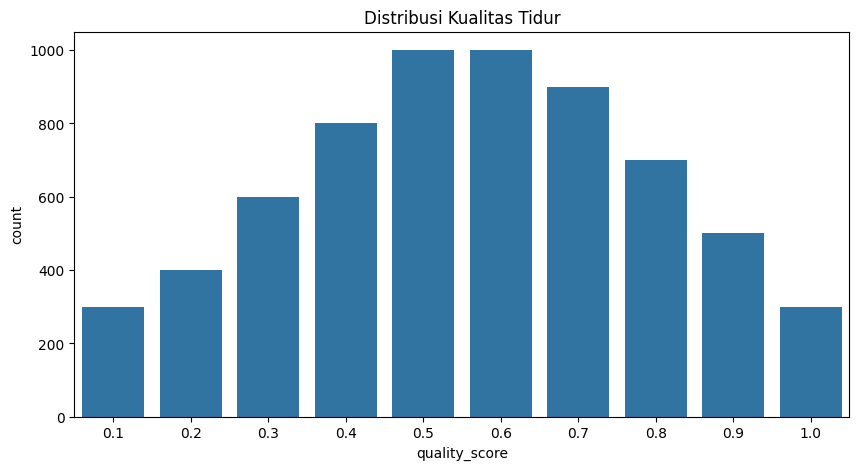

Jumlah data akhir: 6500


In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=balanced_df,
    x='quality_score'
)

plt.title('Distribusi Kualitas Tidur')

plt.show()

print("Jumlah data akhir:", len(balanced_df))

### Insights
1. Dataset setelah undersampling berhasil diseragamkan membentuk kurva lonceng (distribusi normal). Hal ini merepresentasikan kondisi riil di mana nilai ekstrem lebih sedikit dibanding nilai menengah.

2. Kualitas tidur menengah dengan skor 0.5 dan 0.6 menjadi kelompok dominan dengan masing-masing memiliki tepat 1.000 sampel data.  
3. Nilai kualitas tidur terendah (0.1) dan tertinggi (1.0) dibatasi masing-masing hanya 300 sampel untuk meminimalkan efek pencilan (outliers).
4. Evaluasi model tidak boleh hanya mengandalkan metrik akurasi global (global accuracy). Tim AI perlu memantau f1-score per kelas menggunakan classification report atau menerapkan weighted metrics untuk mengukur performa model secara objektif pada kelas yang minim sampel (seperti skor 0.1 dan 1.0).  
5. Dengan total 6.500 data akhir yang terdistribusi secara proporsional, model Sleep Scoring dapat belajar secara adil tanpa risiko bias pada kelas tertentu, sehingga menghasilkan prediksi yang lebih stabil dan objektif.

## Reoder sesuai kontrak

In [ ]:
columns_order = [
    'id', 'user_id', 'date', 'bedtime', 'wake_time',
    'duration_hours', 'interruptions', 'sleep_debt_hours', 'quality_score'
]
df_final = balanced_df[columns_order]

In [ ]:
# Menghapus missing values dan duplikat
balanced_df = balanced_df.dropna()
balanced_df = balanced_df.drop_duplicates()

print(f"Data Clean: {balanced_df.shape}")

Data Clean: (6500, 10)


## Output Dataset

In [ ]:
df_final.to_csv('sleep_logs_clean.csv', index=False)

df_sleep_logs = pd.read_csv("/content/sleep_logs_clean.csv")

In [ ]:
df_sleep_logs.head(50)

,id,user_id,date,bedtime,wake_time,duration_hours,interruptions,sleep_debt_hours,quality_score
0,slp_26400,26400,2026-04-23,23:08,07:23,8.24,5,0.00,0.6
1,slp_111583,11583,2026-05-10,21:19,04:16,6.94,1,1.06,0.9
2,slp_87840,87840,2026-04-23,21:12,04:26,7.22,8,0.78,0.4
3,slp_82065,82065,2026-05-08,01:30,08:50,7.33,3,0.67,0.6
4,slp_35311,35311,2026-05-22,20:39,06:10,9.51,1,0.00,0.8
5,slp_100043,43,2026-04-30,21:18,05:59,8.68,0,0.00,0.9
6,slp_88602,88602,2026-05-11,00:34,07:28,6.90,3,1.10,0.5
7,slp_44830,44830,2026-05-13,01:33,07:18,5.75,2,2.25,0.5
8,slp_113667,13667,2026-04-26,04:14,08:49,4.57,0,3.43,0.9
9,slp_90797,90797,2026-05-06,20:13,03:37,7.39,3,0.61,0.6


## Data Dictionary

<div align="center">

| Kolom | Keterangan |
| :--- | :--- |
| `id` | ID unik per entri |
| `user_id` | ID anonim pengguna |
| `date` | Tanggal tidur, format `YYYY-MM-DD` |
| `bedtime` | Waktu mulai tidur, format `HH:MM` |
| `wake_time` | Waktu bangun, format `HH:MM` |
| `duration_hours` | Total durasi tidur dalam jam |
| `interruptions` | Jumlah kali terbangun |
| `sleep_debt_hours` | Akumulasi utang tidur dalam jam |
| `quality_score` | Label skor kualitas tidur, `0.0 – 1.0` |

</div>

## Conclusion
Proses preprocessing pada dataset sleep logs berhasil mengintegrasikan data multi-sumber, membersihkan duplikasi, dan menghasilkan dataset akhir dengan jumlah 6.500 baris (sleep_logs_clean.csv). Tahapan undersampling terbukti sukses membentuk distribusi kualitas tidur yang terkontrol, menghilangkan ketimpangan data ekstrem, dan membuat dataset ini berada dalam kondisi siap pakai untuk pemodelan AI.